In [85]:
pip install scikit-image


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Importações 

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

# Filtros para realce das bolinhas

## Filtro Passa-Alta

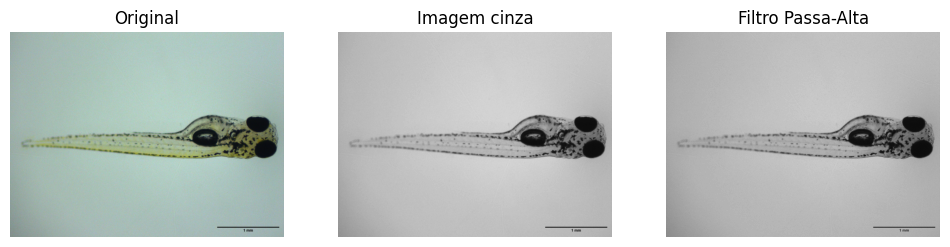

In [2]:
# Carregar a imagem
# img = cv2.imread('Snap-93.jpg')
# img = cv2.imread('BCT1.jpg')
# img = cv2.imread('BCT05.jpg')
img = cv2.imread('c1.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Filtro Passa-Alta (Realce de Bordas)
kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])  # Kernel de realce
high_pass = cv2.filter2D(gray, -1, kernel)

# Mostrar resultados
plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Imagem cinza")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(high_pass, cmap='gray')
plt.title("Filtro Passa-Alta")
plt.axis('off')

plt.show()



## Filtro CLAHE

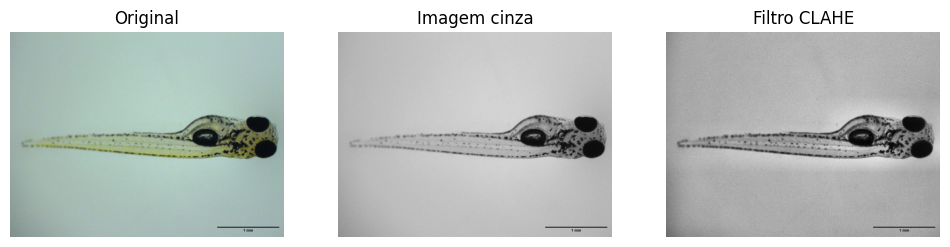

In [3]:
# Carregar a imagem
# img = cv2.imread('Snap-93.jpg')
# img = cv2.imread('BCT1.jpg')
# img = cv2.imread('BCT05.jpg')
img = cv2.imread('c1.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)


# Mostrar resultados
plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Imagem cinza")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(enhanced, cmap='gray')
plt.title("Filtro CLAHE")
plt.axis('off')

plt.show()



## Teste sem filtro

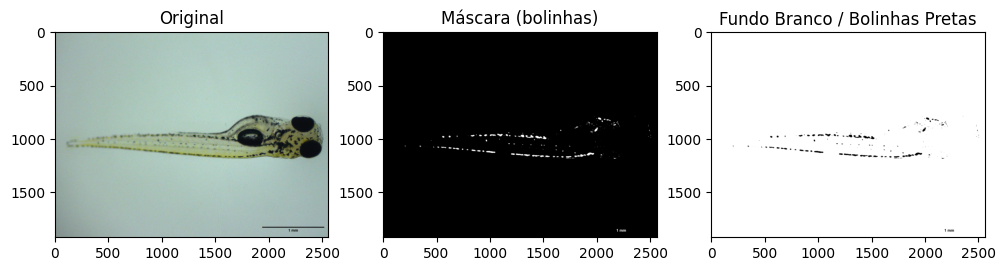

In [9]:


# Carregar a imagem
#img = cv2.imread('Snap-93.jpg')
#img = cv2.imread('BCT1.jpg')
#img = cv2.imread('BCT05.jpg')
img = cv2.imread('c1.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Limiarização 
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Remover ruído com morfologia
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2,2))
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

# Rotular objetos
labels = label(clean)

# Criar máscara vazia
mask = np.zeros_like(gray, dtype=np.uint8)

# Filtrar por área e excentricidade
for region in regionprops(labels):
    if 1 < region.area < 3000:  # tamanho das bolinhas
        if region.eccentricity < 0.99:  # descartar objetos alongados
            for coord in region.coords:
                mask[coord[0], coord[1]] = 255

# Resultado final: somente bolinhas
result = cv2.bitwise_and(img, img, mask=mask)

# Fundo branco / bolinhas pretas
fundo_branco_bolinhas_pretas = cv2.bitwise_not(mask)

# Mostrar resultados
plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Máscara (bolinhas)")
plt.subplot(1,3,3); plt.imshow(fundo_branco_bolinhas_pretas, cmap='gray'); plt.title("Fundo Branco / Bolinhas Pretas")

plt.show()


## Teste com filtro passa-alta

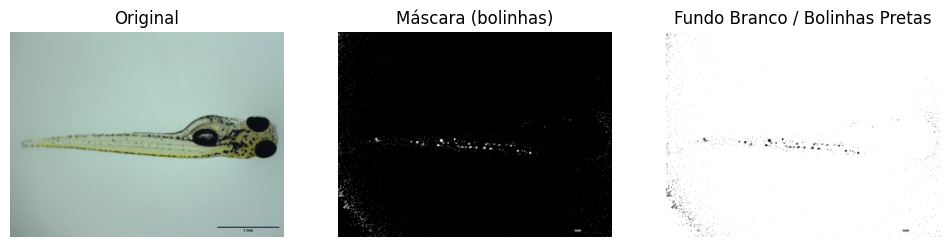

In [109]:

# Carregar a imagem
#img = cv2.imread('Snap-93.jpg')
#img = cv2.imread('BCT1.jpg')
#img = cv2.imread('BCT05.jpg')
img = cv2.imread('c1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Filtro passa-alta
kernel1 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
high_pass = cv2.filter2D(gray, -1, kernel1)

# Limiarização
_, thresh = cv2.threshold(high_pass, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Remover ruído com morfologia
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2,2))
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

# Rotular objetos
labels = label(clean)

# Criar máscara vazia
mask = np.zeros_like(high_pass, dtype=np.uint8)

# Filtrar por área e excentricidade
for region in regionprops(labels):
    if 1 <= region.area < 3000:
        if region.eccentricity < 0.81:
            for coord in region.coords:
                mask[coord[0], coord[1]] = 255

# Fundo branco / bolinhas pretas
fundo_branco_bolinhas_pretas = cv2.bitwise_not(mask)

# Mostrar resultados
plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Máscara (bolinhas)"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(fundo_branco_bolinhas_pretas, cmap='gray'); plt.title("Fundo Branco / Bolinhas Pretas"); plt.axis('off')
plt.show()


## Teste com filtro CLAHE

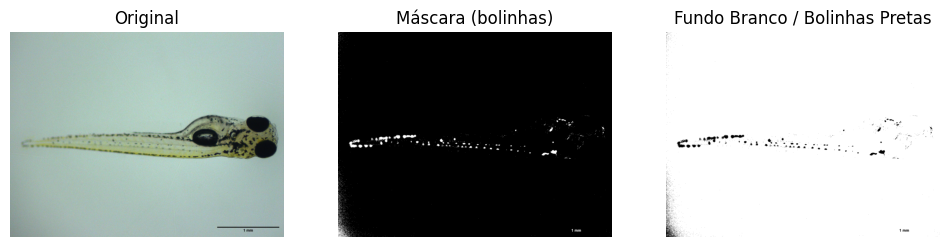

In [122]:


# Carregar a imagem
#img = cv2.imread('Snap-93.jpg')
#img = cv2.imread('BCT1.jpg')
#img = cv2.imread('BCT05.jpg')
img = cv2.imread('c1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Filtro CLAHE (contraste local)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

# Limiarização
_, thresh = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Remover ruído com morfologia
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2,2))
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

# Rotular objetos
labels = label(clean)

# Criar máscara vazia
mask = np.zeros_like(enhanced, dtype=np.uint8)

# Filtrar por área e excentricidade
for region in regionprops(labels):
    if 0 <= region.area < 5000:  # tamanho das bolinhas
        if region.eccentricity < 0.99:  # descartar objetos alongados
            for coord in region.coords:
                mask[coord[0], coord[1]] = 255

# Fundo branco / bolinhas pretas
fundo_branco_bolinhas_pretas = cv2.bitwise_not(mask)

# Mostrar resultados
plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Máscara (bolinhas)"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(fundo_branco_bolinhas_pretas, cmap='gray'); plt.title("Fundo Branco / Bolinhas Pretas"); plt.axis('off')
plt.show()


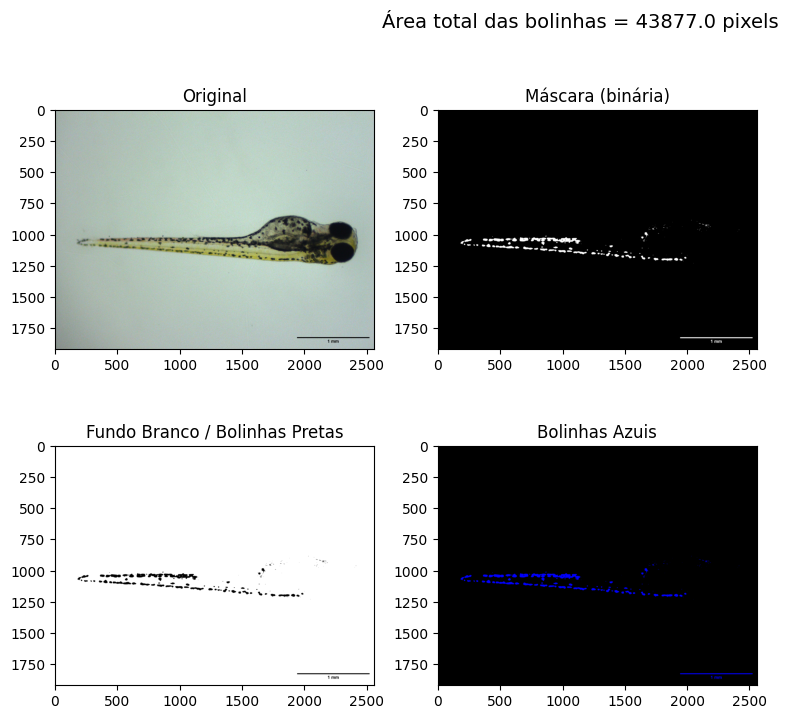

In [185]:

# Carregar a imagem

#img = cv2.imread('Snap-93.jpg')
img = cv2.imread('BCT1.jpg')
#img = cv2.imread('BCT05.jpg')
#img = cv2.imread('c1.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Inverter (bolinhas escuras viram brancas)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Remover ruído com morfologia
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2,2))
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

# Rotular objetos
labels = label(clean)

# Criar máscara vazia
mask = np.zeros_like(gray, dtype=np.uint8)

# Variável para área total
area_total = 0

# Filtrar por área e excentricidade
for region in regionprops(labels):
    if 0 < region.area < 222076:  # tamanho das bolinhas
        if region.eccentricity < 1:  # descartar objetos alongados
            area_total += region.area
            for coord in region.coords:
                mask[coord[0], coord[1]] = 255

# Resultado original (bolinhas aplicadas na imagem)
result = cv2.bitwise_and(img, img, mask=mask)

# Diferentes visualizações
fundo_branco_bolinhas_pretas = 255 - mask
fundo_preto_bolinhas_brancas = mask

# Bolinhas em cor artificial 
bolinhas_coloridas = np.zeros_like(img)
bolinhas_coloridas[mask == 255] = [255, 0, 0]  

# Mostrar resultados
plt.figure(figsize=(14,8))
plt.subplot(2,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(2,3,2); plt.imshow(mask, cmap='gray'); plt.title("Máscara (binária)")
plt.subplot(2,3,4); plt.imshow(fundo_branco_bolinhas_pretas, cmap='gray'); plt.title("Fundo Branco / Bolinhas Pretas")
plt.subplot(2,3,5); plt.imshow(cv2.cvtColor(bolinhas_coloridas, cv2.COLOR_BGR2RGB)); plt.title("Bolinhas Azuis")
plt.suptitle(f"Área total das bolinhas = {area_total} pixels", fontsize=14)
plt.show()
